In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

# Generate alternating stationary and non-stationary time series
def generate_alternating_ts(n_periods=1000, segment_length=50, seed=42):
    np.random.seed(seed)
    ts = []
    change_points = []
    for i in range(n_periods // segment_length):
        if i % 2 == 0:
            # Stationary: AR(1) process
            ar_coeff = 0.7
            noise = np.random.normal(0, 1, segment_length)
            segment = np.zeros(segment_length)
            for t in range(1, segment_length):
                segment[t] =ar_coeff * segment[t-1] + noise[t]
        else:
            # Non-Stationary: Random walk
            drift = np.random.uniform(-0.1, 0.1)
            segment = np.cumsum(np.random.normal(drift, 1, segment_length))
        ts.extend(segment)
        change_points.append(len(ts))
    return np.array(ts), change_points

def rolling_tests(ts, window=50, alpha=0.05):
    adf_results, kpss_results, pp_results, sigma_results = [], [], [], []
    for i in range(window, len(ts)):
        adf_p = adfuller(ts[i-window:i])[1]
        kpss_p = kpss(ts[i-window:i], regression='c')[1]
        pp_p = PhillipsPerron(ts[i-window:i]).pvalue
        
        adf_results.append(adf_p < alpha)  # True if stationary
        kpss_results.append(kpss_p > alpha)  # True if stationary (KPSS has opposite null)
        pp_results.append(pp_p < alpha)  # True if stationary
        
        # 2-Sigma Method (Dakos et al.): Detects variance increase as early warning signal
        window_std = np.std(ts[i-window:i])
        mean_std = np.mean([np.std(ts[max(0, j-window):j]) for j in range(i-window, i)])
        sigma_results.append(window_std > 2 * mean_std)  # Flag if variance is > 2-sigma threshold
    
    return np.array(adf_results), np.array(kpss_results), np.array(pp_results), np.array(sigma_results)

def plot_results(ts, adf_results, kpss_results, pp_results, sigma_results, change_points, window):
    fig, axes = plt.subplots(4, 1, figsize=(24, 16), sharex=True)
    tests = [("ADF", adf_results), ("KPSS", kpss_results), ("PP", pp_results), ("2-Sigma", sigma_results)]
    colors = ['red', 'blue', 'green', 'purple']
    time_indices = np.arange(window, len(ts))
    
    for ax, (test_name, results), color in zip(axes, tests, colors):
        ax.plot(ts, label='Time Series', color='black', alpha=0.5)
        ax.scatter(time_indices[results], np.zeros(np.sum(results)), color=color, alpha=0.5, label=f'{test_name} Non-Stationary')
        for cp in change_points:
            ax.axvline(cp, color='black', linestyle='--', alpha=0.7, label='Change Point' if cp == change_points[0] else "")
        ax.set_title(f"{test_name} Test Results")
        ax.legend()
    
    plt.xlabel("Time")
    plt.show()

# Run the analysis
ts, change_points = generate_alternating_ts()
adf_results, kpss_results, pp_results, sigma_results = rolling_tests(ts)


/tmp/ipykernel_552144/2670070978.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts[i-window:i], regression='c')[1]
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_552144/2670070978.py:32: InterpolationWarning: The test statistic is outside of the range of p-values available in the
lo

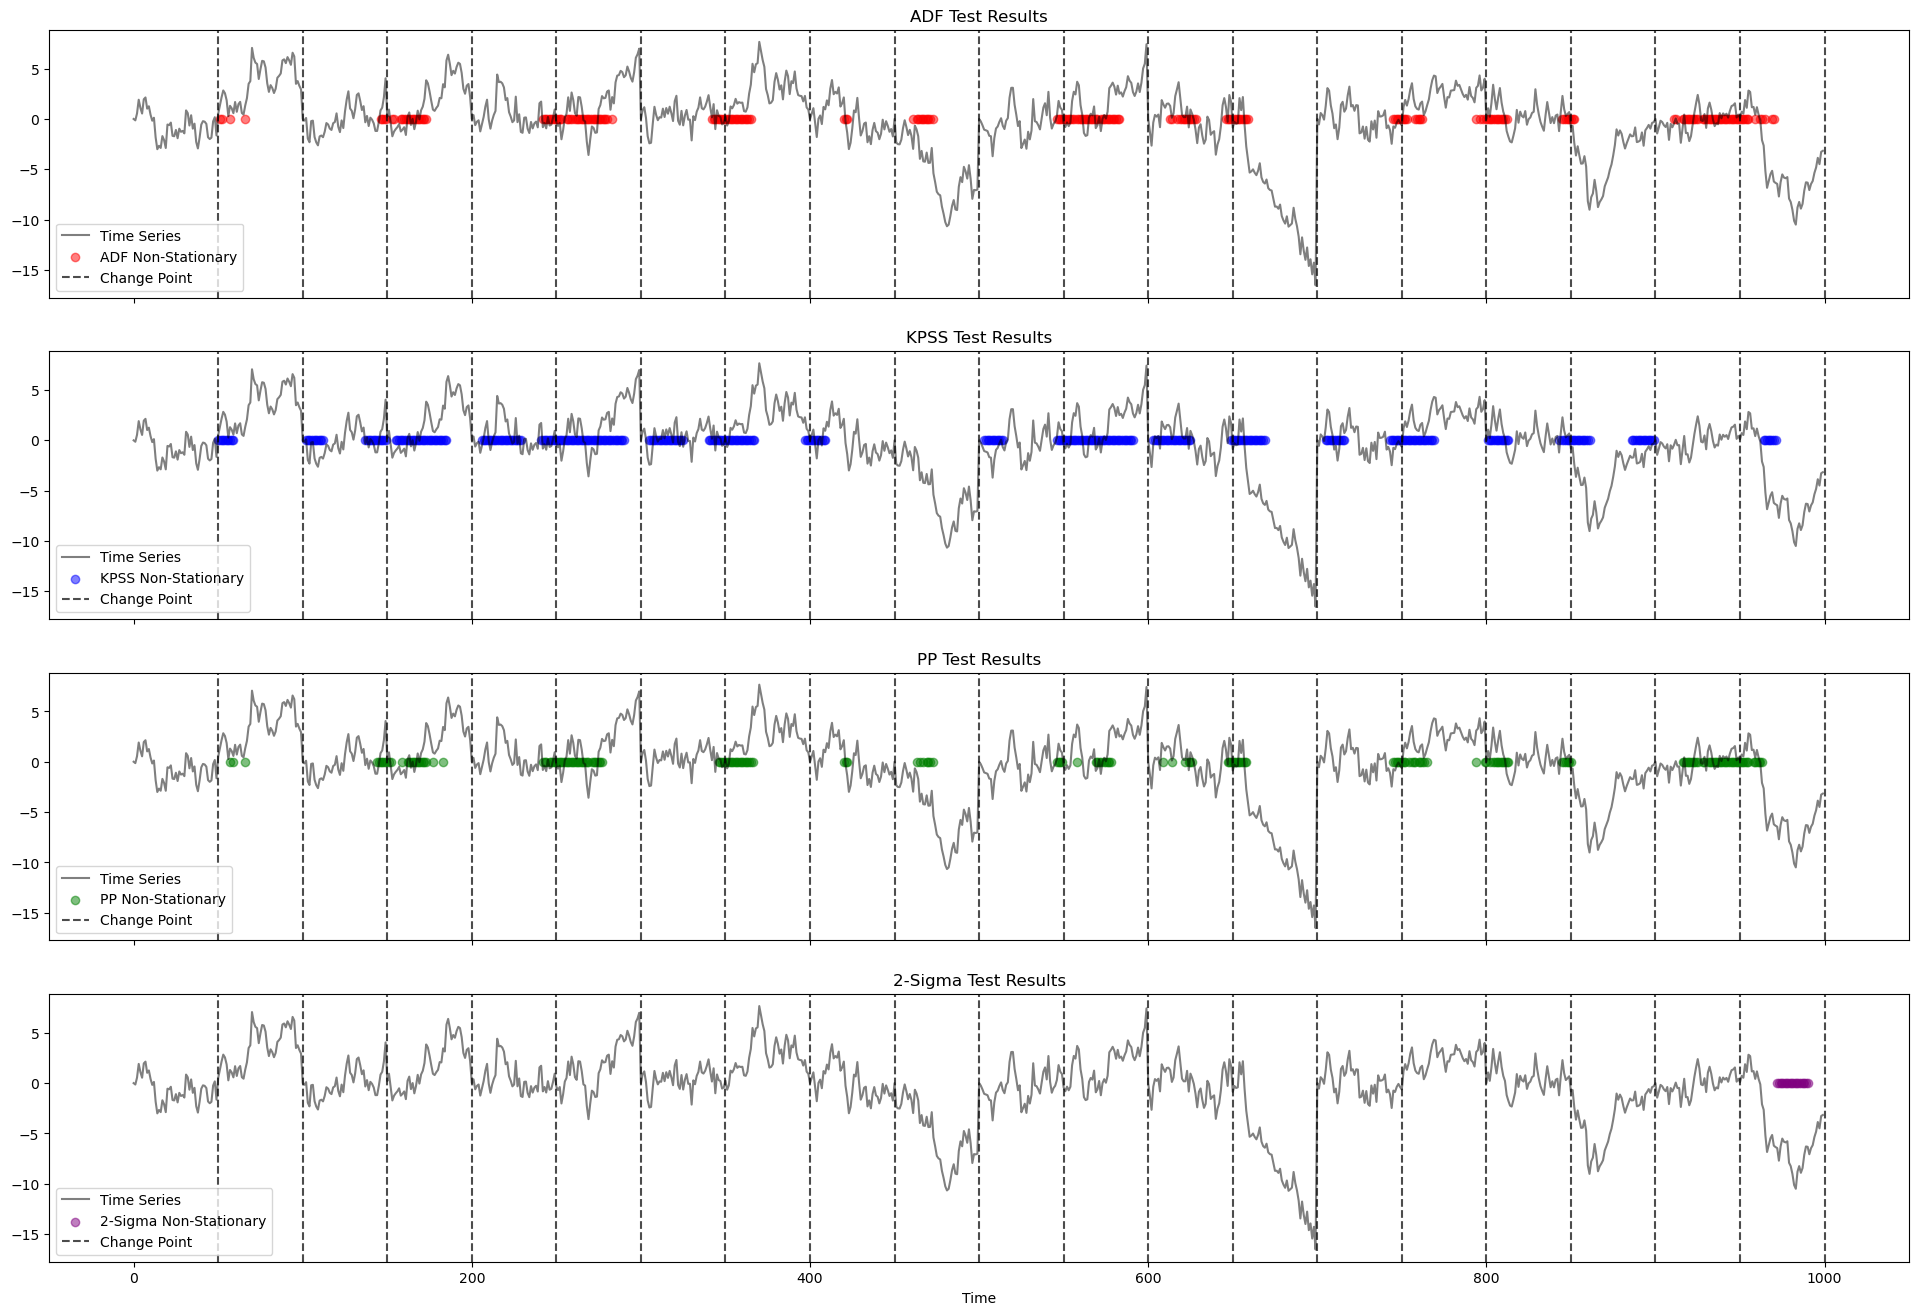

In [22]:
plot_results(ts, adf_results, kpss_results, pp_results, sigma_results, change_points, 50)

/tmp/ipykernel_141535/824920034.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts[i-window:i, var], regression='c')[1]
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_141535/824920034.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the

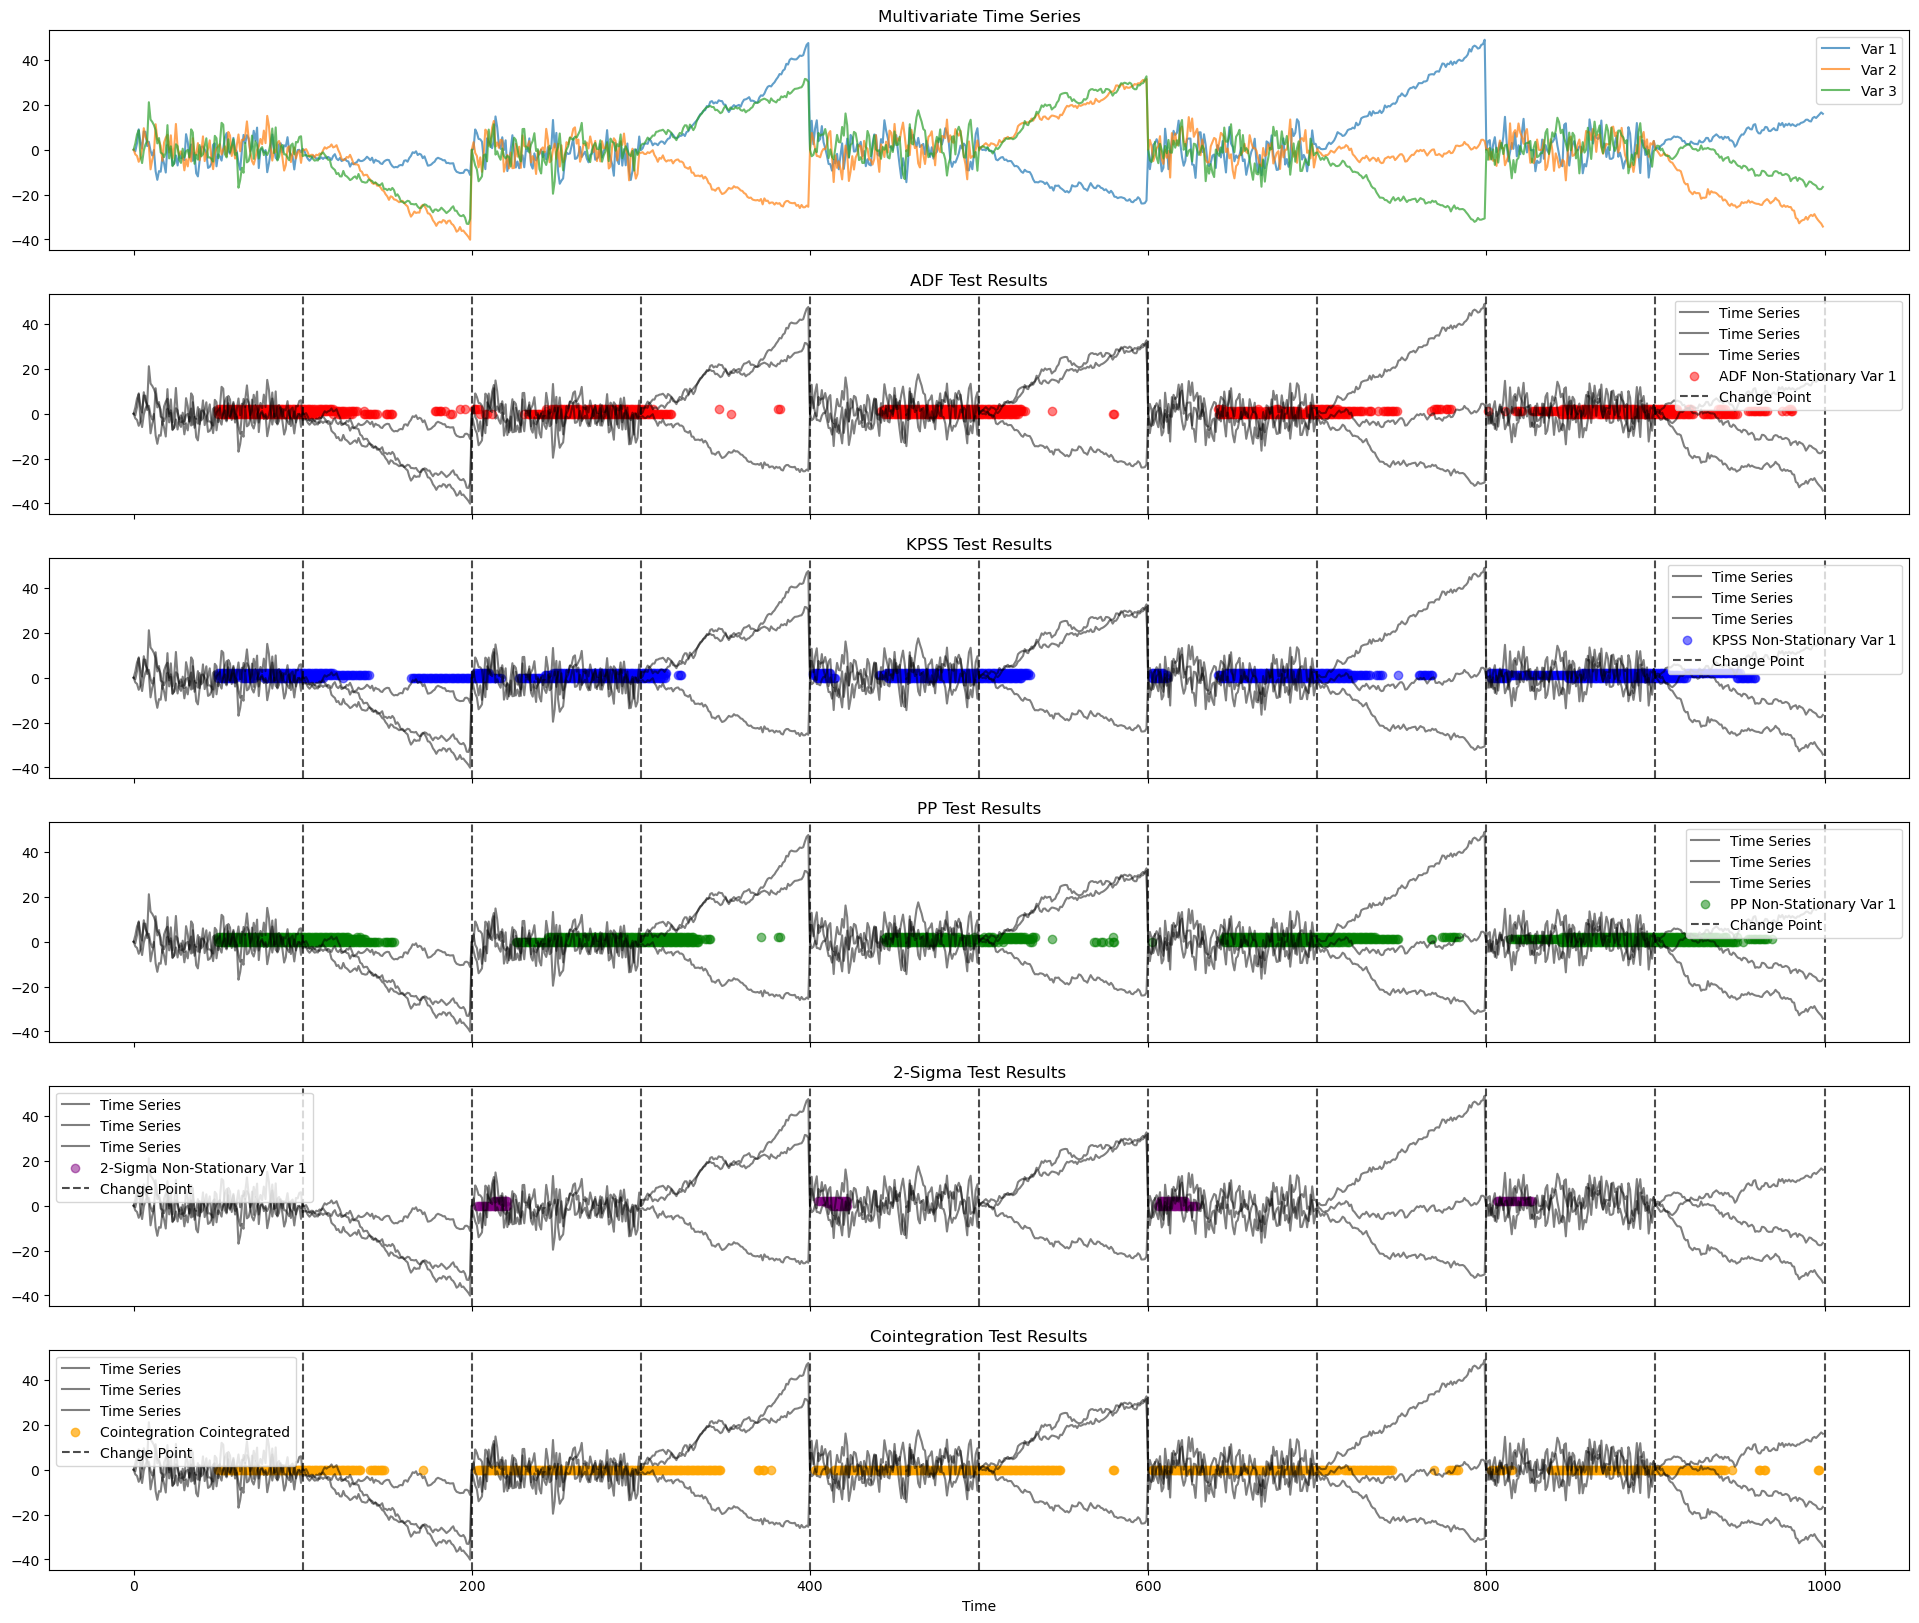

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Generate alternating stationary and non-stationary multivariate time series
def generate_multivariate_ts(n_periods=1000, n_variables=3, segment_length=50, seed=42):
    np.random.seed(seed)
    ts = np.empty((n_periods, n_variables))
    change_points = []
    
    for i in range(n_periods // segment_length):
        for var in range(n_variables):
            if i % 2 == 0:
                # Stationary: AR(1) process
                ar_coeff = 0.5
                noise = np.random.normal(0, 5, segment_length)
                segment = np.zeros(segment_length)
                for t in range(1, segment_length):
                    segment[t] = ar_coeff * segment[t-1] + noise[t]
            else:
                # Non-Stationary: Random walk
                drift = np.random.uniform(-0.5, 0.5)
                segment = np.cumsum(np.random.normal(drift, 1, segment_length))
            
            ts[i*segment_length:(i+1)*segment_length, var] = segment
        change_points.append((i + 1) * segment_length)
    
    return ts, change_points

def johansen_cointegration_test(ts, window=50, significance_level=0.05):
    # Perform rolling Johansen cointegration test
    n_obs, n_variables = ts.shape
    cointegration_results = []
    
    for i in range(window, n_obs):
        johansen_test = coint_johansen(ts[i-window:i], det_order=0, k_ar_diff=1)
        trace_statistic = johansen_test.lr1
        critical_values = johansen_test.cvt[:, 1]  # 5% significance level
        # Check if any of the trace statistics exceed the critical values
        cointegration_results.append(np.any(trace_statistic > critical_values))
    
    return np.array(cointegration_results)

def rolling_tests_multivariate(ts, window=50, alpha=0.05):
    n_variables = ts.shape[1]
    adf_results, kpss_results, pp_results, sigma_results = [], [], [], []
    
    for i in range(window, len(ts)):
        adf_p_values, kpss_p_values, pp_p_values, sigma_flags = [], [], [], []
        
        for var in range(n_variables):
            adf_p = adfuller(ts[i-window:i, var])[1]
            kpss_p = kpss(ts[i-window:i, var], regression='c')[1]
            pp_p = PhillipsPerron(ts[i-window:i, var]).pvalue
            
            adf_p_values.append(adf_p)
            kpss_p_values.append(kpss_p)
            pp_p_values.append(pp_p)
            
            # 2-Sigma Method (Dakos et al.): Detects variance increase as early warning signal
            window_std = np.std(ts[i-window:i, var])
            mean_std = np.mean([np.std(ts[max(0, j-window):j, var]) for j in range(i-window, i)])
            sigma_flags.append(window_std > 2 * mean_std)
        
        # Store results for each variable
        adf_results.append(np.array(adf_p_values) < alpha)  # True if stationary
        kpss_results.append(np.array(kpss_p_values) > alpha)  # True if stationary
        pp_results.append(np.array(pp_p_values) < alpha)  # True if stationary
        sigma_results.append(np.array(sigma_flags))  # Flag if variance > 2-sigma threshold
    
    return np.array(adf_results), np.array(kpss_results), np.array(pp_results), np.array(sigma_results)

def plot_results_multivariate(ts, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, change_points, window):
    n_variables = ts.shape[1]
    fig, axes = plt.subplots(6, 1, figsize=(24, 20), sharex=True)
    
    tests = [("ADF", adf_results), ("KPSS", kpss_results), ("PP", pp_results), ("2-Sigma", sigma_results), ("Cointegration", cointegration_results)]
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    time_indices = np.arange(window, len(ts))
    
    # Plot the time series with different colors for each variable
    for var in range(n_variables):
        axes[0].plot(ts[:, var], label=f'Var {var+1}', color=f'C{var}', alpha=0.7)
    axes[0].set_title("Multivariate Time Series")
    axes[0].legend()
    
    # Plot each test result for each variable
    for ax, (test_name, results), color in zip(axes[1:], tests, colors):
        ax.plot(ts, label='Time Series', color='black', alpha=0.5)
        
        # Mark non-stationary periods for each variable
        if test_name != "Cointegration":
            for var in range(n_variables):
                ax.scatter(time_indices[results[:, var]], np.ones(np.sum(results[:, var])) * var, 
                           color=color, alpha=0.5, label=f'{test_name} Non-Stationary Var {var+1}' if var == 0 else "")
        else:
            # For Cointegration, plot where cointegration is True
            ax.scatter(time_indices[cointegration_results], np.zeros(np.sum(cointegration_results)), 
                       color=color, alpha=0.7, label=f'{test_name} Cointegrated')

        # Mark change points
        for cp in change_points:
            ax.axvline(cp, color='black', linestyle='--', alpha=0.7, label='Change Point' if cp == change_points[0] else "")
        
        ax.set_title(f"{test_name} Test Results")
        ax.legend()
    
    plt.xlabel("Time")
    plt.show()

# Run the analysis for multivariate time series
ts, change_points = generate_multivariate_ts(segment_length=100)

# Perform rolling Johansen cointegration test
cointegration_results = johansen_cointegration_test(ts, window=50)

# Perform rolling stationarity tests
adf_results, kpss_results, pp_results, sigma_results = rolling_tests_multivariate(ts)

# Plot results
plot_results_multivariate(ts, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, change_points, window=50)

from sklearn.metrics import roc_curve, auc

def generate_true_labels(n_periods=1000, n_variables=3, segment_length=50):
    true_labels = np.zeros((n_periods, n_variables))
    
    for i in range(n_periods // segment_length):
        label = 1 if i % 2 == 1 else 0  # Alternating between stationary (0) and non-stationary (1)
        true_labels[i*segment_length:(i+1)*segment_length, :] = label
    
    return true_labels


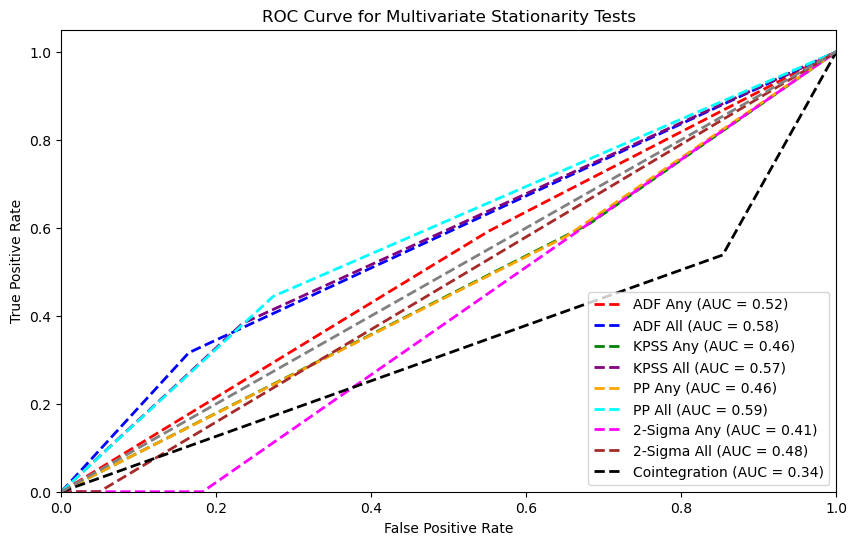

In [5]:
def generate_true_labels(n_periods=1000, n_variables=3, segment_length=50):
    true_labels = np.zeros(n_periods)
    
    for i in range(n_periods // segment_length):
        label = 1 if i % 2 == 1 else 0  # Alternating between stationary (0) and non-stationary (1)
        true_labels[i*segment_length:(i+1)*segment_length] = label
    
    return true_labels[segment_length:].astype(int)  # Ensure matching dimensions


def plot_roc_multivariate(true_labels, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, window):
    test_results = {
        "ADF Any": adf_results.any(axis=1).astype(int),
        "ADF All": adf_results.all(axis=1).astype(int),
        "KPSS Any": kpss_results.any(axis=1).astype(int),
        "KPSS All": kpss_results.all(axis=1).astype(int),
        "PP Any": pp_results.any(axis=1).astype(int),
        "PP All": pp_results.all(axis=1).astype(int),
        "2-Sigma Any": sigma_results.any(axis=1).astype(int),
        "2-Sigma All": sigma_results.all(axis=1).astype(int),
        "Cointegration": cointegration_results.astype(int)
    }
    
    plt.figure(figsize=(10, 6))
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'black']
    
    for (test_name, y_score), color in zip(test_results.items(), colors):
        y_true = true_labels  # Ensure single-dimensional y_true
        
        # Ensure valid ROC calculation
        if np.sum(y_true == 1) == 0 or np.sum(y_true == 0) == 0:
            print(f"Skipping {test_name} due to missing class labels.")
            continue
        
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=color, lw=2, linestyle='--', label=f'{test_name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multivariate Stationarity Tests')
    plt.legend(loc='lower right')
    plt.show()

# Generate true labels for evaluation
true_labels = generate_true_labels()

# Plot ROC curves
plot_roc_multivariate(true_labels, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, window=50)

/tmp/ipykernel_154999/2577132274.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts[i-window:i, var], regression='c')[1]
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_154999/2577132274.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in t

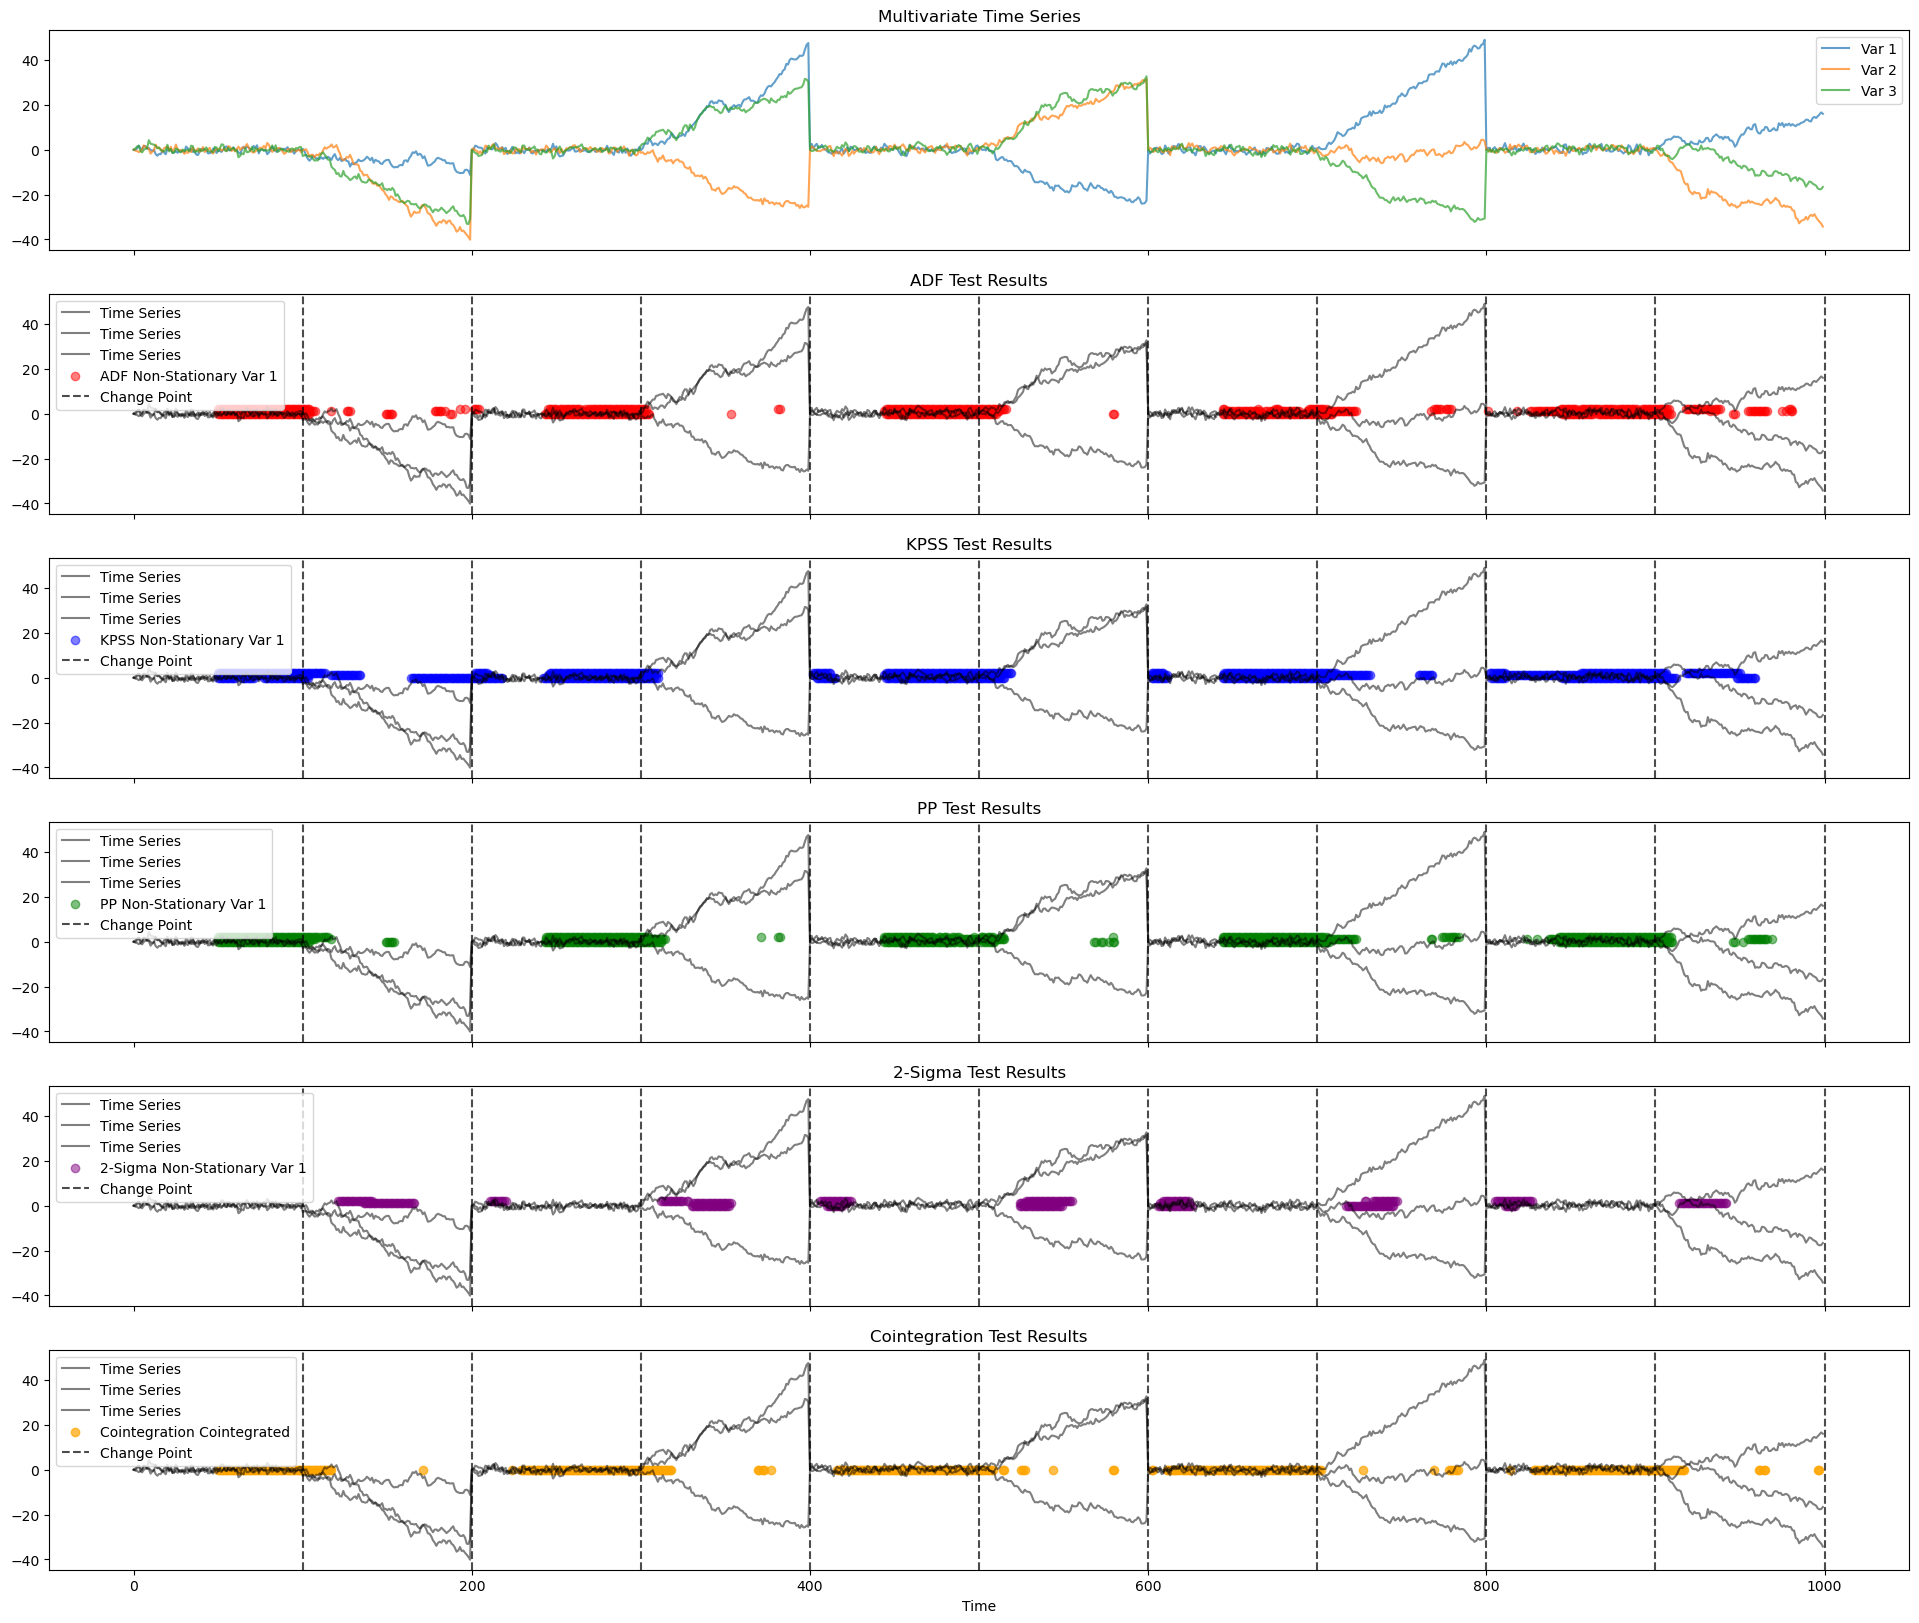

ValueError: Found input variables with inconsistent numbers of samples: [900, 950]

<Figure size 1000x600 with 0 Axes>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def generate_normalised_multivariate_ts(n_periods=1000, n_variables=3, segment_length=50, seed=42):
    np.random.seed(seed)
    ts = np.empty((n_periods, n_variables))
    change_points = []
    
    for i in range(n_periods // segment_length):
        for var in range(n_variables):
            if i % 2 == 0:
                # Stationary: AR(1) process
                ar_coeff = 0.5
                noise = np.random.normal(0, 1, segment_length)
                segment = np.zeros(segment_length)
                for t in range(1, segment_length):
                    segment[t] = ar_coeff * segment[t-1] + noise[t]
            else:
                # Non-Stationary: Random walk
                drift = np.random.uniform(-0.5, 0.5)
                segment = np.cumsum(np.random.normal(drift, 1, segment_length))
            
            ts[i*segment_length:(i+1)*segment_length, var] = segment
        change_points.append((i + 1) * segment_length)
    
    return ts, change_points

def johansen_cointegration_test(ts, window=50, significance_level=0.05):
    # Perform rolling Johansen cointegration test
    n_obs, n_variables = ts.shape
    cointegration_results = []
    
    for i in range(window, n_obs):
        johansen_test = coint_johansen(ts[i-window:i], det_order=0, k_ar_diff=1)
        trace_statistic = johansen_test.lr1
        critical_values = johansen_test.cvt[:, 1]  # 5% significance level
        # Check if any of the trace statistics exceed the critical values
        cointegration_results.append(np.any(trace_statistic > critical_values))
    
    return np.array(cointegration_results)

def rolling_tests_multivariate(ts, window=50, alpha=0.05):
    n_variables = ts.shape[1]
    adf_results, kpss_results, pp_results, sigma_results = [], [], [], []
    
    for i in range(window, len(ts)):
        adf_p_values, kpss_p_values, pp_p_values, sigma_flags = [], [], [], []
        
        for var in range(n_variables):
            adf_p = adfuller(ts[i-window:i, var])[1]
            kpss_p = kpss(ts[i-window:i, var], regression='c')[1]
            pp_p = PhillipsPerron(ts[i-window:i, var]).pvalue
            
            adf_p_values.append(adf_p)
            kpss_p_values.append(kpss_p)
            pp_p_values.append(pp_p)
            
            # 2-Sigma Method (Dakos et al.): Detects variance increase as early warning signal
            window_std = np.std(ts[i-window:i, var])
            mean_std = np.mean([np.std(ts[max(0, j-window):j, var]) for j in range(i-window, i)])
            sigma_flags.append(window_std > 2 * mean_std)
        
        # Store results for each variable
        adf_results.append(np.array(adf_p_values) < alpha)  # True if stationary
        kpss_results.append(np.array(kpss_p_values) > alpha)  # True if stationary
        pp_results.append(np.array(pp_p_values) < alpha)  # True if stationary
        sigma_results.append(np.array(sigma_flags))  # Flag if variance > 2-sigma threshold
    
    return np.array(adf_results), np.array(kpss_results), np.array(pp_results), np.array(sigma_results)

def plot_results_multivariate(ts, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, change_points, window):
    n_variables = ts.shape[1]
    fig, axes = plt.subplots(6, 1, figsize=(24, 20), sharex=True)
    
    tests = [("ADF", adf_results), ("KPSS", kpss_results), ("PP", pp_results), ("2-Sigma", sigma_results), ("Cointegration", cointegration_results)]
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    time_indices = np.arange(window, len(ts))
    
    # Plot the time series with different colors for each variable
    for var in range(n_variables):
        axes[0].plot(ts[:, var], label=f'Var {var+1}', color=f'C{var}', alpha=0.7)
    axes[0].set_title("Multivariate Time Series")
    axes[0].legend()
    
    # Plot each test result for each variable
    for ax, (test_name, results), color in zip(axes[1:], tests, colors):
        ax.plot(ts, label='Time Series', color='black', alpha=0.5)
        
        # Mark non-stationary periods for each variable
        if test_name != "Cointegration":
            for var in range(n_variables):
                ax.scatter(time_indices[results[:, var]], np.ones(np.sum(results[:, var])) * var, 
                           color=color, alpha=0.5, label=f'{test_name} Non-Stationary Var {var+1}' if var == 0 else "")
        else:
            # For Cointegration, plot where cointegration is True
            ax.scatter(time_indices[cointegration_results], np.zeros(np.sum(cointegration_results)), 
                       color=color, alpha=0.7, label=f'{test_name} Cointegrated')

        # Mark change points
        for cp in change_points:
            ax.axvline(cp, color='black', linestyle='--', alpha=0.7, label='Change Point' if cp == change_points[0] else "")
        
        ax.set_title(f"{test_name} Test Results")
        ax.legend()
    
    plt.xlabel("Time")
    plt.show()

s_length = 100

# Run the analysis for multivariate time series
ts, change_points = generate_normalised_multivariate_ts(segment_length=s_length)

# Perform rolling Johansen cointegration test
cointegration_results = johansen_cointegration_test(ts, window=50)

# Perform rolling stationarity tests
adf_results, kpss_results, pp_results, sigma_results = rolling_tests_multivariate(ts)

# Plot results
plot_results_multivariate(ts, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, change_points, window=50)

from sklearn.metrics import roc_curve, auc

# def generate_true_labels(n_periods=1000, n_variables=3, segment_length=50):
#     true_labels = np.zeros((n_periods, n_variables))
    
#     for i in range(n_periods // segment_length):
#         label = 1 if i % 2 == 1 else 0  # Alternating between stationary (0) and non-stationary (1)
#         true_labels[i*segment_length:(i+1)*segment_length, :] = label
    
#     return true_labels

def generate_true_labels(n_periods=1000, n_variables=3, segment_length=50):
    true_labels = np.zeros(n_periods)
    
    for i in range(n_periods // segment_length):
        label = 1 if i % 2 == 1 else 0  # Alternating between stationary (0) and non-stationary (1)
        true_labels[i*segment_length:(i+1)*segment_length] = label
    
    return true_labels[segment_length:].astype(int)  # Ensure matching dimensions


def plot_roc_multivariate(true_labels, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, window):
    test_results = {
        "ADF Any": adf_results.any(axis=1).astype(int),
        "ADF All": adf_results.all(axis=1).astype(int),
        "KPSS Any": kpss_results.any(axis=1).astype(int),
        "KPSS All": kpss_results.all(axis=1).astype(int),
        "PP Any": pp_results.any(axis=1).astype(int),
        "PP All": pp_results.all(axis=1).astype(int),
        "2-Sigma Any": sigma_results.any(axis=1).astype(int),
        "2-Sigma All": sigma_results.all(axis=1).astype(int),
        "Cointegration": cointegration_results.astype(int)
    }
    
    plt.figure(figsize=(10, 6))
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'black']
    
    for (test_name, y_score), color in zip(test_results.items(), colors):
        y_true = true_labels  # Ensure single-dimensional y_true
        
        # Ensure valid ROC calculation
        if np.sum(y_true == 1) == 0 or np.sum(y_true == 0) == 0:
            print(f"Skipping {test_name} due to missing class labels.")
            continue
        
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=color, lw=2, linestyle='--', label=f'{test_name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multivariate Stationarity Tests')
    plt.legend(loc='lower right')
    plt.show()

# Generate true labels for evaluation
true_labels = generate_true_labels(segment_length=s_length)

# Plot ROC curves
plot_roc_multivariate(true_labels, adf_results, kpss_results, pp_results, sigma_results, cointegration_results, window=50)